#  SWIGGY SALES ANALYSIS
 
 

 ........... Import libraries............... 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

 .............Import Data...............

In [2]:
df = pd.read_excel('swiggy_data.xlsx')

In [3]:
df.head(20)  #checking the first staring 20 rows of the dataset

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0
5,Karnataka,Bengaluru,2025-07-08,Srinidhi Sagar Deluxe,Kengeri,Recommended,Srinidhi Sagar Special,312.0,4.0,0
6,Karnataka,Bengaluru,2025-01-21,Srinidhi Sagar Deluxe,Kengeri,Recommended,Garlic Naan,98.0,4.0,34
7,Karnataka,Bengaluru,2025-04-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Pista,137.0,4.0,0
8,Karnataka,Bengaluru,2025-05-02,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Panneer Butter Masala,241.0,4.4,29
9,Karnataka,Bengaluru,2025-07-30,Srinidhi Sagar Deluxe,Kengeri,North Indian Gravy,Dal Tadka,195.0,4.9,51


In [4]:
df.tail(20)  #checking the last staring 20 rows of the dataset

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197410,Sikkim,Gangtok,2025-08-21,Mama's Kitchen,Gangtok,Beverages,Milk coffee ...,42.0,4.4,0
197411,Sikkim,Gangtok,2025-05-19,Mama's Kitchen,Gangtok,Momos,Veg steam momo,85.0,4.4,0
197412,Sikkim,Gangtok,2025-08-08,Mama's Kitchen,Gangtok,Momos,Veg fried momo ...,84.0,4.3,20
197413,Sikkim,Gangtok,2025-08-24,Mama's Kitchen,Gangtok,Momos,Veg chilli momo ...,112.0,4.4,0
197414,Sikkim,Gangtok,2025-04-19,Mama's Kitchen,Gangtok,Momos,Paneer steam momo ...,84.0,4.4,0
197415,Sikkim,Gangtok,2025-05-10,Mama's Kitchen,Gangtok,Momos,Paneer fried momo ...,98.0,4.4,0
197416,Sikkim,Gangtok,2025-04-07,Mama's Kitchen,Gangtok,Momos,Paneer chilli momo ...,112.0,4.4,0
197417,Sikkim,Gangtok,2025-05-29,Mama's Kitchen,Gangtok,Momos,Corn cheese steam momo ...,112.0,4.4,0
197418,Sikkim,Gangtok,2025-06-20,Mama's Kitchen,Gangtok,Momos,Corn cheese fried momo ...,126.0,4.4,0
197419,Sikkim,Gangtok,2025-06-05,Mama's Kitchen,Gangtok,Momos,Corn cheese chilli momo ...,140.0,4.4,0


...........Meta Data...................

In [5]:
print("no of rows ;",df.shape[0])

no of rows ; 197430


In [6]:
print("no of fields ;",df.shape[1]) 

no of fields ; 10


In [7]:
df.info

<bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2   

................DATA TYPES..............

In [8]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [9]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


...............KPI'S..............


total sales....

In [10]:
total_sales = df["Price (INR)"].sum()
print("Total Sales(INR):", round(total_sales, 2))

Total Sales(INR): 53012505.77


average rating 

In [11]:
average_rating = df["Price (INR)"].mean()
print("Average Rating:", round(average_rating, 2))

Average Rating: 268.51


average order value 


In [12]:
average_order_value = df["Price (INR)"].mean()
print("Average Order Value(INR):", round(average_order_value, 2))

Average Order Value(INR): 268.51


rating counting

In [13]:
ratings_count = df["Rating Count"].sum()
print("Ratings Count:", round(ratings_count, 2))


Ratings Count: 5591574


total orders

In [14]:
total_orders = df["Order Date"].count()  # = len(df)
print("Total_Orders:", round(total_orders, 2))

Total_Orders: 197430


charts desgin

monthly sales trend

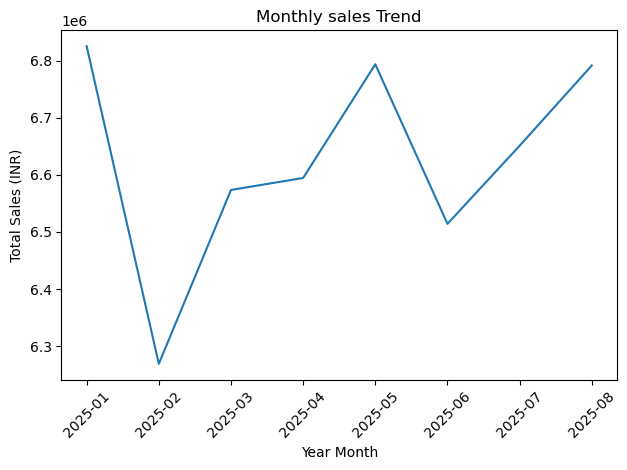

In [17]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Year Month"] = df["Order Date"].dt.to_period("M").astype(str)
monthly_revenue = df.groupby("Year Month")["Price (INR)"].sum().reset_index()
plt.figure()
plt.plot(monthly_revenue["Year Month"], monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Year Month")
plt.ylabel("Total Sales (INR)")
plt.title("Monthly sales Trend")
plt.tight_layout()
plt.show()

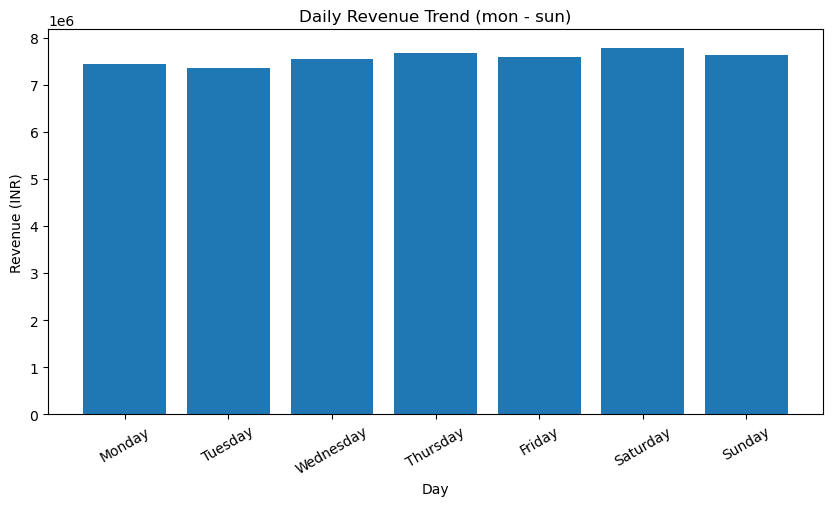

In [23]:
df ["DayName"] = pd.to_datetime(df["Order Date"]).dt.day_name()

Daily_revenue = df.groupby("DayName")["Price (INR)"].sum().reindex(
    [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday",
    ]
)

plt.figure(figsize=(10, 5))
plt.bar(Daily_revenue.index, Daily_revenue.values)
plt.title("Daily Revenue Trend (mon - sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)


plt.show()

TOTAL SALES BY FOOD TYPES (VEG VS NON-VEG)

In [25]:
non_veg_keywords = ["chicken", "mutton", "fish", "egg", "prawn", "kabab","non-veg"]

df["Food category"]= np.where(
    df["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False),
    "Non-Veg",
    "Veg"
)

In [26]:
Food_revenue = (df.groupby("Food category")["Price (INR)"].sum().reset_index())

In [28]:
fig = px.pie(
    Food_revenue,
    values="Price (INR)",
    names="Food category",
    hole=0.5,
    title="Revenue contribution: Veg vs Non-Veg",
)
fig.update_traces(textposition="inside", textinfo="percent+label",pull=[0.05,0 ])
fig.update_layout(height=500, margin=dict(t=60, b=40, l=40, r=40))
fig.show()

Total sales by state

In [30]:
fig = px.bar(
    df.groupby("State", as_index=False)["Price (INR)"].sum().sort_values("Price (INR)", ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue by State"
)
fig.update_layout(height=600, yaxis=dict(autorange="reversed"))
fig.show()

Quarterly performance  Summary

In [32]:
df["Order_Date"] = pd.to_datetime(df["Order Date"])
df["Quarter"] = df["Order_Date"].dt.to_period("Q").astype(str)
quarterly_summary = (df.groupby("Quarter", as_index=False).agg(
    Total_Sales=("Price (INR)", "sum"),Avg_Rating=("Rating", "mean"),Total_Orders=("Order Date", "count"))
.sort_values("Quarter"))
quarterly_summary ["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary ["Avg_Rating"]

quarterly_summary


,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667822.0,4.342643,73096
1,2025Q2,19902257.0,4.340011,74163
2,2025Q3,13442427.0,4.342359,50171


TOP 5 CITIES BY SALES

In [36]:
top_5_cities = (
    df.groupby("City")["Price (INR)"]
    .sum().nlargest(5).sort_values().reset_index())
fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"]
)
fig.show()
